In [190]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS

# Init test

## Without trainset

In [191]:
model = ANFIS(input_size=2, fuzzy_rules=3, outputs=1)

In [192]:
print("input_size: ", model._input_size)
print("input_dtype: ", model._dtype)
print("rule_reduced: ", model._rule_reduced)
print("output_type: ", model._output_type)
print("outputs: ", model._outputs)

input_size:  2
input_dtype:  torch.float32
rule_reduced:  False
output_type:  regression
outputs:  1


In [193]:
x = torch.rand(10, 2)
x

tensor([[0.7495, 0.3064],
        [0.0548, 0.0355],
        [0.7950, 0.8476],
        [0.3438, 0.8176],
        [0.8854, 0.2833],
        [0.8498, 0.6548],
        [0.2274, 0.6537],
        [0.4108, 0.0556],
        [0.1874, 0.1508],
        [0.2632, 0.3250]])

In [194]:
model(x)

tensor([ 0.0896,  0.3707, -0.1686, -0.0293,  0.0839, -0.3958, -0.2069,  0.3068,
         0.3320,  0.2387], grad_fn=<SqueezeBackward1>)

In [195]:
model.predict(x)

array([ 0.0896353 ,  0.37069023, -0.16860572, -0.02929929,  0.08391153,
       -0.3958263 , -0.2068775 ,  0.3068175 ,  0.33203813,  0.23872374],
      dtype=float32)

In [196]:
model.intermediate_values(x)

(tensor([[0.4641, 0.2278, 0.4341, 0.3383, 0.1660, 0.3164, 0.2535, 0.1244, 0.2371],
         [0.4570, 0.1087, 0.4796, 0.2970, 0.0706, 0.3117, 0.1002, 0.0238, 0.1051],
         [0.4008, 0.3537, 0.2949, 0.2892, 0.2553, 0.2128, 0.2570, 0.2268, 0.1891],
         [0.4508, 0.4459, 0.3357, 0.2750, 0.2720, 0.2048, 0.1095, 0.1083, 0.0815],
         [0.4177, 0.1912, 0.3950, 0.3032, 0.1388, 0.2868, 0.3904, 0.1787, 0.3692],
         [0.3949, 0.8072, 0.3147, 0.2851, 0.5827, 0.2272, 0.3149, 0.6436, 0.2509],
         [0.4298, 0.8813, 0.3426, 0.2624, 0.5381, 0.2092, 0.0976, 0.2001, 0.0778],
         [0.5777, 0.1446, 0.6030, 0.3614, 0.0905, 0.3773, 0.1492, 0.0374, 0.1558],
         [0.4784, 0.1524, 0.4814, 0.2948, 0.0939, 0.2967, 0.1071, 0.0341, 0.1078],
         [0.4749, 0.2470, 0.4403, 0.2886, 0.1500, 0.2675, 0.1096, 0.0570, 0.1016]]),
 tensor([[0.1812, 0.0889, 0.1695, 0.1321, 0.0648, 0.1235, 0.0989, 0.0486, 0.0925],
         [0.2339, 0.0556, 0.2455, 0.1520, 0.0362, 0.1595, 0.0513, 0.0122, 0.0538],
  

In [197]:
model.get_premises()

tensor([[[ 0.8691,  0.8530,  0.4863],
         [ 0.5427,  0.2279,  0.6030],
         [ 0.1947,  0.5210,  0.9571]],

        [[ 0.5905,  0.1302, -0.0985],
         [ 0.1503,  0.6394,  0.6505],
         [ 0.6026,  0.4834, -0.3200]]])

In [198]:
model.set_premises(model.get_premises()*2)
model.get_premises()

tensor([[[ 1.7382,  1.7059,  0.9726],
         [ 1.0854,  0.4558,  1.2059],
         [ 0.3893,  1.0420,  1.9142]],

        [[ 1.1809,  0.2605, -0.1970],
         [ 0.3006,  1.2789,  1.3011],
         [ 1.2052,  0.9669, -0.6400]]])

In [199]:
model.get_consequents()

tensor([[[-0.6704,  0.1743,  0.8499],
         [-0.0503, -0.4277, -0.5660],
         [ 0.9043,  0.8012,  0.8701],
         [-0.9971, -0.3382, -0.2398],
         [-0.8496, -0.8576, -0.3237],
         [-0.6385,  0.0601,  0.4286],
         [ 0.7748,  0.4206, -0.9110],
         [-0.6524, -0.7026,  0.4021],
         [ 0.3501, -0.4122,  0.2991]]])

In [200]:
model.set_consequents(model.get_consequents()*2)
model.get_consequents()

tensor([[[-1.3407,  0.3486,  1.6999],
         [-0.1006, -0.8553, -1.1321],
         [ 1.8087,  1.6025,  1.7401],
         [-1.9941, -0.6764, -0.4797],
         [-1.6993, -1.7153, -0.6473],
         [-1.2770,  0.1203,  0.8573],
         [ 1.5497,  0.8413, -1.8220],
         [-1.3047, -1.4052,  0.8042],
         [ 0.7002, -0.8244,  0.5983]]])

In [201]:
model.init_premises(x_train=x)
model.get_premises()

tensor([[[0.2076, 8.0000, 0.0548],
         [0.2076, 8.0000, 0.4701],
         [0.2076, 8.0000, 0.8854]],

        [[0.2030, 8.0000, 0.0355],
         [0.2030, 8.0000, 0.4416],
         [0.2030, 8.0000, 0.8476]]])

In [202]:
model.fuzzy_rules, model.rules

(3, 9)

In [203]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 1,0.207646,8.0,0.054789,0.203022,8.0,0.035518
Fuzzy rule 2,0.207646,8.0,0.470081,0.203022,8.0,0.441563
Fuzzy rule 3,0.207646,8.0,0.885374,0.203022,8.0,0.847607


In [204]:
model.consequents_structure

[         c0 (x0)   c1 (x1)        c2
 rule 1 -1.340712  0.348563  1.699899
 rule 2 -0.100561 -0.855302 -1.132075
 rule 3  1.808693  1.602493  1.740111
 rule 4 -1.994145 -0.676449 -0.479697
 rule 5 -1.699264 -1.715290 -0.647344
 rule 6 -1.277002  0.120280  0.857260
 rule 7  1.549659  0.841287 -1.821999
 rule 8 -1.304718 -1.405166  0.804204
 rule 9  0.700156 -0.824399  0.598268]

In [205]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.207646     8.0  0.054789  0.203022     8.0  0.035518
Fuzzy rule 2  0.207646     8.0  0.470081  0.203022     8.0  0.441563
Fuzzy rule 3  0.207646     8.0  0.885374  0.203022     8.0  0.847607


In [206]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -1.340712  0.348563  1.699899
rule 2 -0.100561 -0.855302 -1.132075
rule 3  1.808693  1.602493  1.740111
rule 4 -1.994145 -0.676449 -0.479697
rule 5 -1.699264 -1.715290 -0.647344
rule 6 -1.277002  0.120280  0.857260
rule 7  1.549659  0.841287 -1.821999
rule 8 -1.304718 -1.405166  0.804204
rule 9  0.700156 -0.824399  0.598268




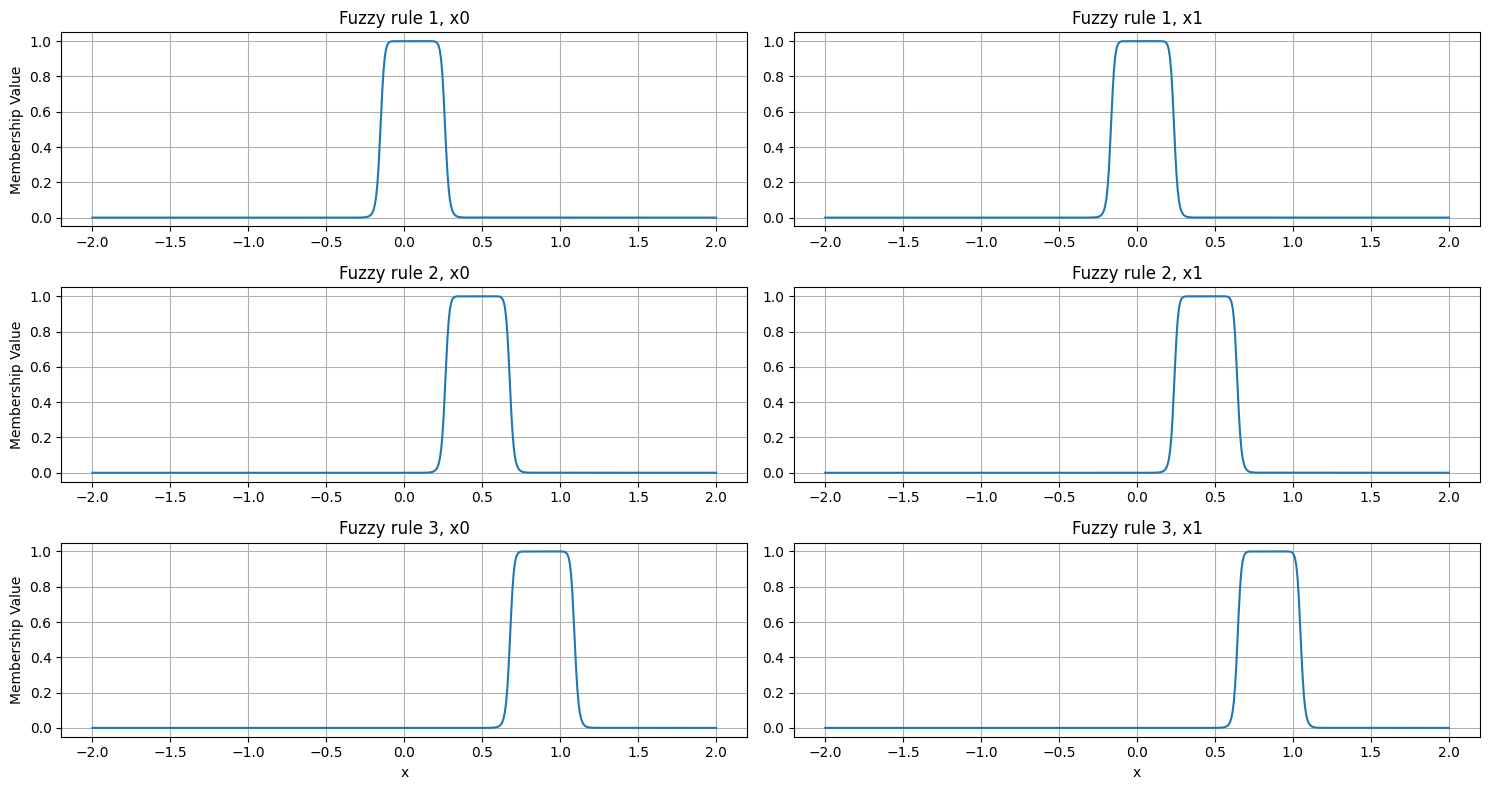

In [207]:
model.plot_premises()

## With trainset

In [208]:
x = torch.randn(10, 2)
x_p = torch.zeros_like(x)
x_p += x
x_p[x < 0] = x_p[x < 0]*-1
x = x/(torch.max(x_p)*1.1)
x

tensor([[-0.4279,  0.4275],
        [-0.9091,  0.8605],
        [ 0.3634, -0.5514],
        [ 0.3758,  0.1584],
        [-0.0112, -0.0032],
        [ 0.0879,  0.4011],
        [-0.3636,  0.5003],
        [ 0.0655,  0.0926],
        [ 0.0380, -0.5522],
        [ 0.1957,  0.8033]])

In [209]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=1)

In [210]:
print("input_size: ", model._input_size)
print("dtype: ", model._dtype)
print("rule_reduced: ", model._rule_reduced)
print("output_type: ", model._output_type)
print("outputs: ", model._outputs)

input_size:  2
input_dtype:  torch.float32
rule_reduced:  False
output_type:  regression
outputs:  1


In [211]:
x = torch.rand(10, 2)
x

tensor([[0.3061, 0.1906],
        [0.3362, 0.1346],
        [0.6241, 0.6244],
        [0.0208, 0.1327],
        [0.1773, 0.4219],
        [0.7406, 0.7935],
        [0.3748, 0.8014],
        [0.4886, 0.8546],
        [0.0115, 0.9215],
        [0.6468, 0.7428]])

In [212]:
model(x)

tensor([-0.0805, -0.0555,  1.9287, -0.6521, -0.1358,  2.1938,  1.8874,  2.0283,
        -0.6341,  2.0717], grad_fn=<SqueezeBackward1>)

In [213]:
model.predict(x)

array([-0.08053844, -0.05547284,  1.9287087 , -0.6521013 , -0.13578519,
        2.1938422 ,  1.8873513 ,  2.0283272 , -0.6341141 ,  2.0716565 ],
      dtype=float32)

In [214]:
model.intermediate_values(x)

(tensor([[3.8797e-15, 5.6870e-10, 2.0254e-14, 6.5465e-10, 9.5962e-05, 3.4177e-09,
          6.8220e-06, 1.0000e+00, 3.5615e-05],
         [9.1763e-15, 3.8406e-10, 3.7885e-15, 1.0081e-09, 4.2193e-05, 4.1621e-10,
          2.3893e-05, 1.0000e+00, 9.8644e-06],
         [5.9854e-20, 1.3975e-13, 1.3763e-11, 3.5531e-16, 8.2958e-10, 8.1699e-08,
          4.2727e-09, 9.9760e-03, 9.8246e-01],
         [1.0267e-12, 4.1125e-08, 3.8920e-13, 2.1358e-05, 8.5551e-01, 8.0965e-06,
          4.1922e-06, 1.6792e-01, 1.5892e-06],
         [3.0430e-16, 3.3746e-09, 1.0359e-10, 5.0087e-10, 5.5545e-03, 1.7050e-04,
          8.9069e-08, 9.8776e-01, 3.0321e-02],
         [2.1642e-21, 3.2108e-16, 4.2721e-12, 5.8035e-18, 8.6100e-13, 1.1456e-08,
          5.8625e-11, 8.6975e-06, 1.1572e-01],
         [1.0876e-19, 1.4558e-14, 2.3580e-10, 7.2187e-15, 9.6622e-10, 1.5650e-05,
          4.6126e-10, 6.1739e-05, 1.0000e+00],
         [1.5077e-20, 1.0566e-15, 6.0572e-11, 2.8540e-16, 2.0001e-11, 1.1466e-06,
          2.489

In [215]:
model.get_premises()

tensor([[[ 0.3212,  8.0000, -0.9091],
         [ 0.3212,  8.0000, -0.2666],
         [ 0.3212,  8.0000,  0.3758]],

        [[ 0.3532,  8.0000, -0.5522],
         [ 0.3532,  8.0000,  0.1541],
         [ 0.3532,  8.0000,  0.8605]]])

In [216]:
model.set_premises(model.get_premises()*2)
model.get_premises()

tensor([[[ 0.6425, 16.0000, -1.8182],
         [ 0.6425, 16.0000, -0.5333],
         [ 0.6425, 16.0000,  0.7516]],

        [[ 0.7063, 16.0000, -1.1044],
         [ 0.7063, 16.0000,  0.3083],
         [ 0.7063, 16.0000,  1.7209]]])

In [217]:
model.get_consequents()

tensor([[[-0.3649,  0.2465, -0.7341],
         [ 0.0532, -0.7984,  0.4858],
         [ 0.4380,  0.0147,  0.2248],
         [ 0.1838,  0.8694,  0.7966],
         [-0.1494,  0.7507, -0.9251],
         [-0.2156, -0.2546, -0.6957],
         [-0.5859, -0.1085,  0.1533],
         [-0.9527, -0.9616,  0.3943],
         [ 0.8557,  0.8162,  0.9128]]])

In [218]:
model.set_consequents(model.get_consequents()*2)
model.get_consequents()

tensor([[[-0.7298,  0.4930, -1.4682],
         [ 0.1064, -1.5968,  0.9716],
         [ 0.8760,  0.0294,  0.4496],
         [ 0.3677,  1.7388,  1.5932],
         [-0.2987,  1.5014, -1.8503],
         [-0.4313, -0.5091, -1.3914],
         [-1.1717, -0.2171,  0.3065],
         [-1.9055, -1.9233,  0.7887],
         [ 1.7113,  1.6324,  1.8255]]])

In [219]:
model.fuzzy_rules, model.rules

(3, 9)

In [220]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 1,0.642451,16.0,-1.818182,0.706332,16.0,-1.104407
Fuzzy rule 2,0.642451,16.0,-0.533279,0.706332,16.0,0.308258
Fuzzy rule 3,0.642451,16.0,0.751623,0.706332,16.0,1.720923


In [221]:
model.consequents_structure

[         c0 (x0)   c1 (x1)        c2
 rule 1 -0.729810  0.492965 -1.468165
 rule 2  0.106435 -1.596814  0.971633
 rule 3  0.875967  0.029432  0.449601
 rule 4  0.367683  1.738787  1.593225
 rule 5 -0.298726  1.501351 -1.850266
 rule 6 -0.431289 -0.509136 -1.391437
 rule 7 -1.171719 -0.217066  0.306548
 rule 8 -1.905498 -1.923262  0.788687
 rule 9  1.711341  1.632421  1.825537]

In [222]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.642451    16.0 -1.818182  0.706332    16.0 -1.104407
Fuzzy rule 2  0.642451    16.0 -0.533279  0.706332    16.0  0.308258
Fuzzy rule 3  0.642451    16.0  0.751623  0.706332    16.0  1.720923


In [223]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.729810  0.492965 -1.468165
rule 2  0.106435 -1.596814  0.971633
rule 3  0.875967  0.029432  0.449601
rule 4  0.367683  1.738787  1.593225
rule 5 -0.298726  1.501351 -1.850266
rule 6 -0.431289 -0.509136 -1.391437
rule 7 -1.171719 -0.217066  0.306548
rule 8 -1.905498 -1.923262  0.788687
rule 9  1.711341  1.632421  1.825537




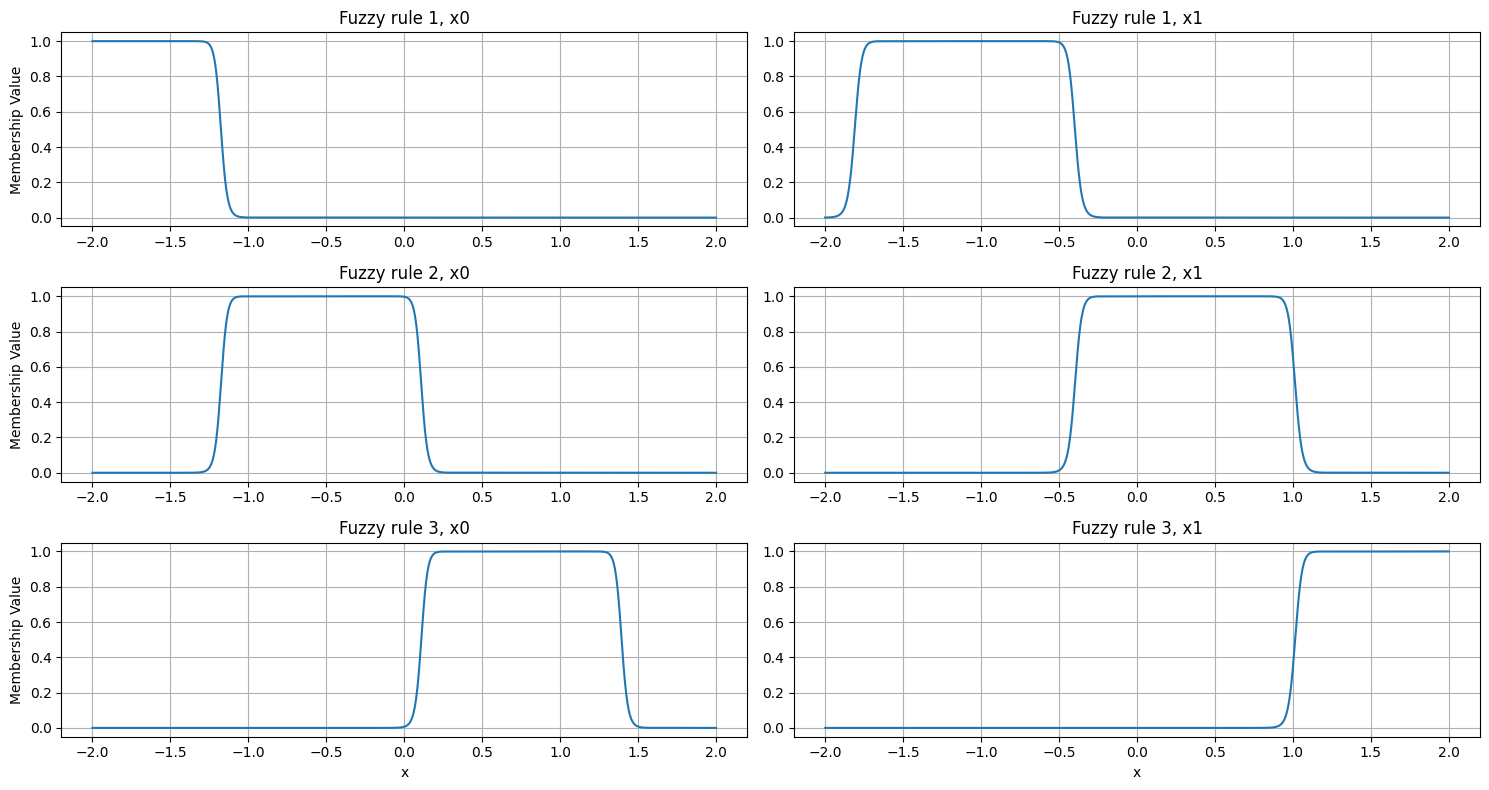

In [224]:
model.plot_premises()

# Gradient testing

## Rule reduced ANFIS

### Regression

#### Single output

In [225]:
x = torch.rand(10, 2)
y = torch.rand(10)
y

tensor([0.4870, 0.6420, 0.9709, 0.9583, 0.6419, 0.8175, 0.3457, 0.3379, 0.6215,
        0.6618])

In [226]:
model = ANFIS(x_train=x, fuzzy_rules=4, outputs=1, output_type='regression', rule_reduced=True)

In [227]:
model.get_premises().shape

torch.Size([2, 4, 3])

In [228]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 1,0.107885,8.0,0.159482,0.155048,8.0,0.034110
Fuzzy rule 2,0.107885,8.0,0.375252,0.155048,8.0,0.344205
Fuzzy rule 3,0.107885,8.0,0.591022,0.155048,8.0,0.654300
Fuzzy rule 4,0.107885,8.0,0.806793,0.155048,8.0,0.964395


In [229]:
model.get_consequents().shape

torch.Size([1, 4, 3])

In [230]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.344784 -0.549870  0.360935
rule 2  0.991892  0.812834 -0.882084
rule 3 -0.703790 -0.655273 -0.998330
rule 4  0.653824 -0.360098 -0.749662




In [231]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [232]:
model.predict(x)

array([-0.09252176, -0.40156972, -1.5598035 , -1.912886  , -1.5665462 ,
       -1.7683756 , -0.6496158 , -1.5872282 , -0.04831076, -0.11844997],
      dtype=float32)

In [233]:
model(x)

tensor([-0.0925, -0.4016, -1.5598, -1.9129, -1.5665, -1.7684, -0.6496, -1.5872,
        -0.0483, -0.1184], grad_fn=<SqueezeBackward1>)

In [234]:
y

tensor([0.4870, 0.6420, 0.9709, 0.9583, 0.6419, 0.8175, 0.3457, 0.3379, 0.6215,
        0.6618])

In [235]:
print(model._fuzzification_layer._premises.grad)

None


In [236]:
print(model._consequent_layer._consequents.grad)

None


In [237]:
model.predict(x)

array([-0.09252176, -0.40156972, -1.5598035 , -1.912886  , -1.5665462 ,
       -1.7683756 , -0.6496158 , -1.5872282 , -0.04831076, -0.11844997],
      dtype=float32)

In [238]:
model(x)

tensor([-0.0925, -0.4016, -1.5598, -1.9129, -1.5665, -1.7684, -0.6496, -1.5872,
        -0.0483, -0.1184], grad_fn=<SqueezeBackward1>)

In [239]:
loss = nn.functional.mse_loss(model(x), y)
loss

tensor(3.3392, grad_fn=<MseLossBackward0>)

In [240]:
loss.backward()

In [241]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-1.3289e+00,  3.2190e-02, -2.1848e-01],
         [-2.9614e+01,  3.5823e-01,  2.5067e+00],
         [ 2.8947e+01, -2.4853e-01,  1.2517e+01],
         [ 9.0144e+00, -2.0328e-01, -1.6883e+00]],

        [[-4.0294e+00,  1.2646e-01, -7.9860e-01],
         [-7.6235e+00,  1.9887e-01, -1.9846e+00],
         [ 1.7972e+01, -2.1774e-01, -4.8944e+00],
         [-7.2964e-01,  1.0927e-02,  2.8811e-01]]])


In [242]:
print(model._consequent_layer._consequents.grad)

tensor([[[-0.0559, -0.0452, -0.1070],
         [-0.1845, -0.2752, -0.4408],
         [-1.3100, -1.3514, -2.3222],
         [-0.2135, -0.2906, -0.3680]]])


#### Multiple outputs

In [243]:
x = torch.rand(10, 3)
y = torch.rand(10, 2)
y

tensor([[0.9618, 0.8716],
        [0.4913, 0.4591],
        [0.9055, 0.2877],
        [0.7087, 0.1931],
        [0.0538, 0.6087],
        [0.1203, 0.4452],
        [0.7103, 0.1563],
        [0.4911, 0.1318],
        [0.2808, 0.4698],
        [0.2948, 0.6532]])

In [244]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=2, output_type='regression', rule_reduced=True)

In [245]:
model.get_premises().shape

torch.Size([3, 3, 3])

In [246]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)  \
Fuzzy rule 1  0.223886     8.0  0.010063  0.214894     8.0  0.085352   
Fuzzy rule 2  0.223886     8.0  0.457834  0.214894     8.0  0.515140   
Fuzzy rule 3  0.223886     8.0  0.905605  0.214894     8.0  0.944928   

                a (x2)  b (x2)    c (x2)  
Fuzzy rule 1  0.163756     8.0  0.157308  
Fuzzy rule 2  0.163756     8.0  0.484819  
Fuzzy rule 3  0.163756     8.0  0.812331  


In [247]:
model.get_consequents().shape

torch.Size([2, 3, 4])

In [248]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)   c2 (x2)        c3
rule 1 -0.103494  0.113035  0.154110  0.124297
rule 2 -0.262098 -0.559471 -0.852717  0.192860
rule 3  0.755709 -0.147758 -0.335115  0.658420


- Output 2:
         c0 (x0)   c1 (x1)   c2 (x2)        c3
rule 1  0.536413  0.993668  0.467162 -0.398216
rule 2 -0.609994  0.408992 -0.603236  0.917838
rule 3 -0.331295  0.022959 -0.903332  0.161430




In [249]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [250]:
model.predict(x)

array([[-5.16344428e-01,  5.26104987e-01],
       [ 1.26600415e-01, -3.77877176e-01],
       [ 1.88124612e-01, -8.68451025e-04],
       [-1.67449459e-01,  4.91355032e-01],
       [-5.46706140e-01,  4.65756357e-01],
       [-6.13394231e-02,  2.87654489e-01],
       [-3.54717374e-01,  7.73726940e-01],
       [-6.83345497e-01,  7.56037474e-01],
       [-8.31818700e-01,  9.15057600e-01],
       [ 4.31340933e-03, -1.15658775e-01]], dtype=float32)

In [251]:
model(x)

tensor([[-5.1634e-01,  5.2610e-01],
        [ 1.2660e-01, -3.7788e-01],
        [ 1.8812e-01, -8.6845e-04],
        [-1.6745e-01,  4.9136e-01],
        [-5.4671e-01,  4.6576e-01],
        [-6.1339e-02,  2.8765e-01],
        [-3.5472e-01,  7.7373e-01],
        [-6.8335e-01,  7.5604e-01],
        [-8.3182e-01,  9.1506e-01],
        [ 4.3134e-03, -1.1566e-01]], grad_fn=<SqueezeBackward1>)

In [252]:
y

tensor([[0.9618, 0.8716],
        [0.4913, 0.4591],
        [0.9055, 0.2877],
        [0.7087, 0.1931],
        [0.0538, 0.6087],
        [0.1203, 0.4452],
        [0.7103, 0.1563],
        [0.4911, 0.1318],
        [0.2808, 0.4698],
        [0.2948, 0.6532]])

In [253]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [254]:
model(x)

tensor([[-5.1634e-01,  5.2610e-01],
        [ 1.2660e-01, -3.7788e-01],
        [ 1.8812e-01, -8.6845e-04],
        [-1.6745e-01,  4.9136e-01],
        [-5.4671e-01,  4.6576e-01],
        [-6.1339e-02,  2.8765e-01],
        [-3.5472e-01,  7.7373e-01],
        [-6.8335e-01,  7.5604e-01],
        [-8.3182e-01,  9.1506e-01],
        [ 4.3134e-03, -1.1566e-01]], grad_fn=<SqueezeBackward1>)

In [255]:
loss = nn.functional.mse_loss(model(x), y)
loss

tensor(0.5214, grad_fn=<MseLossBackward0>)

In [256]:
loss.backward()

In [257]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-8.0047e-01,  4.3798e-03, -6.5901e-01],
         [-4.1130e-01,  4.3436e-03,  1.2570e-01],
         [ 8.1082e-01, -1.4082e-02, -5.0700e-01]],

        [[-1.6772e-03, -1.4960e-05, -2.3948e-03],
         [-2.3392e-02, -4.7001e-03, -1.4428e+00],
         [ 2.0640e-02,  1.3809e-04, -2.6440e-02]],

        [[-1.0422e+00,  3.0932e-03, -9.0152e-01],
         [-8.0354e-01,  1.1119e-02, -5.8302e-01],
         [ 3.3160e-01,  1.6664e-04, -3.3432e-01]]])


In [258]:
print(model._consequent_layer._consequents.grad)

tensor([[[-0.0154, -0.0231, -0.0322, -0.1057],
         [-0.2807, -0.3894, -0.2235, -0.6323],
         [-0.0126, -0.0377, -0.0359, -0.0481]],

        [[-0.0027, -0.0054, -0.0078, -0.0279],
         [-0.0093,  0.0622,  0.0210,  0.0836],
         [-0.0325, -0.0863, -0.0829, -0.1111]]])


### Binary classification

#### Single ouput

In [259]:
x = torch.rand(10, 2)
y = torch.randint(0, 2, (10,))
y

tensor([0, 0, 1, 1, 1, 0, 0, 1, 0, 1])

In [260]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=1, output_type='binary', rule_reduced=True)
model.get_premises().shape

torch.Size([2, 3, 3])

In [261]:
model.show_premises_structure()

               a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.23457     8.0  0.001059  0.165124     8.0  0.206645
Fuzzy rule 2  0.23457     8.0  0.470198  0.165124     8.0  0.536894
Fuzzy rule 3  0.23457     8.0  0.939337  0.165124     8.0  0.867142


In [262]:
model.get_consequents().shape

torch.Size([1, 3, 3])

In [263]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.695687 -0.147127  0.494952
rule 2  0.150198 -0.550563  0.433487
rule 3 -0.647082  0.771787 -0.591125




In [264]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [265]:
model.predict(x)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [266]:
model(x)

tensor([0.5445, 0.5916, 0.5781, 0.5965, 0.5578, 0.5235, 0.5722, 0.5465, 0.5358,
        0.3706], grad_fn=<SigmoidBackward0>)

In [267]:
y

tensor([0, 0, 1, 1, 1, 0, 0, 1, 0, 1])

In [268]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [269]:
model(x)

tensor([0.5445, 0.5916, 0.5781, 0.5965, 0.5578, 0.5235, 0.5722, 0.5465, 0.5358,
        0.3706], grad_fn=<SigmoidBackward0>)

In [270]:
loss = nn.functional.binary_cross_entropy(model(x), y.to(model(x).dtype))
loss

tensor(0.7285, grad_fn=<BinaryCrossEntropyBackward0>)

In [271]:
loss.backward()

In [272]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-1.9130e-01,  7.0692e-03, -5.4581e-02],
         [-1.9838e-02,  1.8766e-03,  6.0899e-02],
         [-4.5505e-07, -8.5925e-09,  8.9730e-07]],

        [[ 9.2842e-02, -2.2180e-03,  2.2172e-02],
         [ 3.8196e-01, -5.4061e-03, -1.9314e-01],
         [ 2.0826e-01, -1.3318e-03, -1.3367e-01]]])


In [273]:
print(model._consequent_layer._consequents.grad)

tensor([[[-0.0065, -0.0243, -0.0734],
         [ 0.0659,  0.0885,  0.1808],
         [-0.0615, -0.0563, -0.0657]]])


#### Multiple Outputs

In [274]:
x = torch.rand(10, 2)
y = torch.randint(0, 2, (10, 2))
y

tensor([[0, 1],
        [1, 0],
        [0, 0],
        [1, 1],
        [0, 0],
        [1, 0],
        [1, 1],
        [1, 1],
        [0, 0],
        [0, 1]])

In [275]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=2, output_type='binary', rule_reduced=True)
model.get_premises().shape

torch.Size([2, 3, 3])

In [276]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.192596     8.0  0.053113  0.232037     8.0  0.020736
Fuzzy rule 2  0.192596     8.0  0.438304  0.232037     8.0  0.484810
Fuzzy rule 3  0.192596     8.0  0.823496  0.232037     8.0  0.948884


In [277]:
model.get_consequents().shape

torch.Size([2, 3, 3])

In [278]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.250481 -0.020688  0.391587
rule 2  0.643116 -0.630870 -0.530185
rule 3 -0.928228 -0.390841 -0.614208


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1  0.784132 -0.632371 -0.681268
rule 2  0.420796 -0.897658  0.282894
rule 3 -0.407687  0.075778  0.986720




In [279]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [280]:
model.predict(x)

array([[1, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 0],
       [0, 1]])

In [281]:
model(x)

tensor([[0.6014, 0.3257],
        [0.4788, 0.6281],
        [0.2948, 0.4271],
        [0.2688, 0.3889],
        [0.3114, 0.4541],
        [0.3117, 0.4293],
        [0.3552, 0.4200],
        [0.3950, 0.5750],
        [0.6054, 0.3592],
        [0.1570, 0.6798]], grad_fn=<SigmoidBackward0>)

In [282]:
y

tensor([[0, 1],
        [1, 0],
        [0, 0],
        [1, 1],
        [0, 0],
        [1, 0],
        [1, 1],
        [1, 1],
        [0, 0],
        [0, 1]])

In [283]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [284]:
model(x)

tensor([[0.6014, 0.3257],
        [0.4788, 0.6281],
        [0.2948, 0.4271],
        [0.2688, 0.3889],
        [0.3114, 0.4541],
        [0.3117, 0.4293],
        [0.3552, 0.4200],
        [0.3950, 0.5750],
        [0.6054, 0.3592],
        [0.1570, 0.6798]], grad_fn=<SigmoidBackward0>)

In [285]:
loss = nn.functional.binary_cross_entropy(model(x), y.to(model(x).dtype))
loss

tensor(0.7477, grad_fn=<BinaryCrossEntropyBackward0>)

In [286]:
loss.backward()

In [287]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-8.3209e-02,  2.5107e-03, -2.3763e-02],
         [ 5.8053e-02, -4.9510e-05, -2.2847e-01],
         [-4.4038e-02,  1.3325e-03,  1.2390e-02]],

        [[-1.7330e-01,  3.9912e-03, -7.8538e-02],
         [ 9.4707e-02, -1.7506e-03, -8.9626e-03],
         [ 2.3389e-01, -5.7520e-03, -1.0088e-01]]])


In [288]:
print(model._consequent_layer._consequents.grad)

tensor([[[ 0.0065,  0.0032,  0.0537],
         [-0.0574, -0.0687, -0.1181],
         [ 0.0026,  0.0053,  0.0034]],

        [[-0.0002, -0.0088, -0.0201],
         [ 0.0149, -0.0010,  0.0234],
         [-0.0141, -0.0167, -0.0189]]])


### Multiclass classification

In [289]:
x = torch.rand(10, 2)
y = torch.randint(0, 4, (10,))
y

tensor([0, 0, 1, 2, 1, 0, 0, 1, 3, 1])

In [290]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=4, output_type='multiclass', rule_reduced=True)
model.get_premises().shape

torch.Size([2, 3, 3])

In [291]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.187334     8.0  0.078492  0.214776     8.0  0.127477
Fuzzy rule 2  0.187334     8.0  0.453160  0.214776     8.0  0.557028
Fuzzy rule 3  0.187334     8.0  0.827829  0.214776     8.0  0.986580


In [292]:
model.get_consequents().shape

torch.Size([4, 3, 3])

In [293]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.833022  0.248794 -0.405295
rule 2  0.808147 -0.796289 -0.698498
rule 3  0.709306 -0.981150 -0.345576


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1  0.508555  0.874377  0.253318
rule 2  0.327013  0.503542  0.736024
rule 3  0.794830 -0.966453  0.359208


- Output 3:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.673188  0.810139  0.968354
rule 2  0.875344 -0.749403 -0.154225
rule 3 -0.813681 -0.877361 -0.813534


- Output 4:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.698284 -0.420616 -0.800179
rule 2  0.211394  0.402139 -0.386976
rule 3  0.787375  0.397264  0.458881




In [294]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [295]:
model.predict(x)

array([[1],
       [1],
       [3],
       [1],
       [1],
       [2],
       [3],
       [3],
       [2],
       [1]])

In [296]:
model(x)

tensor([[0.1090, 0.5358, 0.2001, 0.1551],
        [0.1328, 0.4831, 0.2403, 0.1438],
        [0.1241, 0.3746, 0.0488, 0.4525],
        [0.0768, 0.6064, 0.1402, 0.1766],
        [0.1254, 0.4995, 0.2289, 0.1463],
        [0.1329, 0.2804, 0.5163, 0.0704],
        [0.1068, 0.2873, 0.0352, 0.5707],
        [0.0793, 0.1727, 0.0191, 0.7289],
        [0.1727, 0.3695, 0.3859, 0.0720],
        [0.1177, 0.5161, 0.2140, 0.1522]], grad_fn=<SoftmaxBackward0>)

In [297]:
y

tensor([0, 0, 1, 2, 1, 0, 0, 1, 3, 1])

In [298]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [299]:
model(x)

tensor([[0.1090, 0.5358, 0.2001, 0.1551],
        [0.1328, 0.4831, 0.2403, 0.1438],
        [0.1241, 0.3746, 0.0488, 0.4525],
        [0.0768, 0.6064, 0.1402, 0.1766],
        [0.1254, 0.4995, 0.2289, 0.1463],
        [0.1329, 0.2804, 0.5163, 0.0704],
        [0.1068, 0.2873, 0.0352, 0.5707],
        [0.0793, 0.1727, 0.0191, 0.7289],
        [0.1727, 0.3695, 0.3859, 0.0720],
        [0.1177, 0.5161, 0.2140, 0.1522]], grad_fn=<SoftmaxBackward0>)

In [300]:
loss = nn.functional.cross_entropy(model(x), y)
loss.backward()

In [301]:
print(model._fuzzification_layer._premises.grad)

tensor([[[ 9.6434e-02, -1.2105e-03,  5.6289e-02],
         [-8.4191e-01,  1.2908e-02, -4.4081e-01],
         [ 1.1158e-04,  1.1201e-06, -1.7070e-04]],

        [[-1.0308e-08,  1.0076e-10, -6.2108e-09],
         [-8.5733e-02,  1.4402e-03,  4.2108e-02],
         [ 7.3229e-01, -1.1860e-02, -4.0461e-01]]])


In [302]:
print(model._consequent_layer._consequents.grad)

tensor([[[-0.0008, -0.0022, -0.0119],
         [-0.0076, -0.0031, -0.0117],
         [-0.0037, -0.0045, -0.0057]],

        [[ 0.0013,  0.0009,  0.0056],
         [-0.0203, -0.0035, -0.0237],
         [-0.0234, -0.0241, -0.0307]],

        [[ 0.0019,  0.0020,  0.0118],
         [ 0.0118, -0.0021,  0.0126],
         [ 0.0009,  0.0006,  0.0011]],

        [[-0.0023, -0.0008, -0.0055],
         [ 0.0161,  0.0087,  0.0228],
         [ 0.0262,  0.0280,  0.0353]]])


## Regular ANFIS

### Regression

#### Single Output

In [303]:
x = torch.rand(10, 2)
y = torch.rand(10)
y

tensor([0.5502, 0.8215, 0.4998, 0.0191, 0.3905, 0.2322, 0.6494, 0.4756, 0.8630,
        0.5500])

In [304]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=1, output_type='regression')

In [305]:
model.get_premises().shape

torch.Size([2, 3, 3])

In [306]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.173502     8.0  0.013335  0.204158     8.0  0.034341
Fuzzy rule 2  0.173502     8.0  0.360339  0.204158     8.0  0.442657
Fuzzy rule 3  0.173502     8.0  0.707342  0.204158     8.0  0.850973


In [307]:
model.get_consequents().shape

torch.Size([1, 9, 3])

In [308]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.060968 -0.084109  0.920099
rule 2  0.007163 -0.032315 -0.540884
rule 3  0.698601 -0.385244  0.428322
rule 4 -0.882656 -0.165244 -0.201619
rule 5 -0.783351  0.298066 -0.812180
rule 6 -0.431672  0.138327 -0.619348
rule 7 -0.454259  0.052262  0.253306
rule 8 -0.925976 -0.893346 -0.039923
rule 9 -0.996902 -0.544541  0.581436




In [309]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [310]:
model.predict(x)

array([ 0.10978567, -0.43120736, -0.92588973, -0.06443017, -0.6893111 ,
       -0.05321025, -0.7052085 ,  0.9137551 , -0.81205523, -0.5041365 ],
      dtype=float32)

In [311]:
model(x)

tensor([ 0.1098, -0.4312, -0.9259, -0.0644, -0.6893, -0.0532, -0.7052,  0.9138,
        -0.8121, -0.5041], grad_fn=<SqueezeBackward1>)

In [312]:
y

tensor([0.5502, 0.8215, 0.4998, 0.0191, 0.3905, 0.2322, 0.6494, 0.4756, 0.8630,
        0.5500])

In [313]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [314]:
model(x).squeeze()

tensor([ 0.1098, -0.4312, -0.9259, -0.0644, -0.6893, -0.0532, -0.7052,  0.9138,
        -0.8121, -0.5041], grad_fn=<SqueezeBackward0>)

In [315]:
loss = nn.functional.mse_loss(model(x), y)
loss

tensor(1.0994, grad_fn=<MseLossBackward0>)

In [316]:
loss.backward()

In [317]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-3.3462e-01,  1.4911e-03, -2.7288e-01],
         [ 8.7175e-02, -4.6118e-04,  5.2413e-02],
         [-4.6698e-02,  3.4578e-04,  3.3248e-02]],

        [[-2.7635e-03, -1.9447e-05, -3.6473e-03],
         [ 1.0478e+00, -5.0328e-03,  4.5849e-01],
         [-4.1342e-02,  3.7956e-06,  4.2896e-02]]])


In [318]:
print(model._consequent_layer._consequents.grad)

tensor([[[ 0.0047,  0.0030,  0.0875],
         [-0.0032, -0.0078, -0.0141],
         [-0.0012, -0.0750, -0.0881],
         [-0.0596, -0.0386, -0.2045],
         [-0.1723, -0.3279, -0.6116],
         [-0.2171, -0.3944, -0.4886],
         [-0.0502, -0.0107, -0.0733],
         [-0.0085, -0.0095, -0.0143],
         [-0.1393, -0.1618, -0.2357]]])


#### Multiple Outputs

In [319]:
x = torch.rand(10, 2)
y = torch.rand(10, 2)
y

tensor([[0.9077, 0.5329],
        [0.8038, 0.4973],
        [0.0209, 0.6291],
        [0.4831, 0.5474],
        [0.2317, 0.1056],
        [0.3942, 0.2007],
        [0.5053, 0.9508],
        [0.4055, 0.9189],
        [0.6855, 0.3883],
        [0.4675, 0.0368]])

In [320]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=2, output_type='regression')
model.get_premises().shape

torch.Size([2, 3, 3])

In [321]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.232832     8.0  0.022224  0.211968     8.0  0.097120
Fuzzy rule 2  0.232832     8.0  0.487889  0.211968     8.0  0.521055
Fuzzy rule 3  0.232832     8.0  0.953554  0.211968     8.0  0.944991


In [322]:
model.get_consequents().shape

torch.Size([2, 9, 3])

In [323]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.657452 -0.013190  0.818564
rule 2  0.096145 -0.748959  0.132258
rule 3 -0.376345 -0.093311  0.093057
rule 4  0.765617  0.505066  0.090585
rule 5 -0.725822  0.167638  0.041239
rule 6 -0.963166 -0.755707 -0.502376
rule 7 -0.440006  0.878442  0.229565
rule 8 -0.621757  0.636484  0.895739
rule 9  0.759503  0.322661  0.160703


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1  0.726858 -0.476784 -0.706115
rule 2  0.122896 -0.093061 -0.065913
rule 3 -0.112652  0.315634  0.919620
rule 4 -0.469818 -0.896095  0.357620
rule 5  0.855629 -0.969030 -0.219428
rule 6  0.659436 -0.221614 -0.824157
rule 7 -0.702442  0.193982 -0.785461
rule 8  0.801491 -0.235310  0.709924
rule 9 -0.031304 -0.000804 -0.320287




In [324]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [325]:
model(x)

tensor([[-0.0254,  1.1658],
        [ 0.8996,  0.6754],
        [-0.0109,  1.0960],
        [ 0.4962,  0.0453],
        [-0.3394, -0.3017],
        [-1.6915, -0.7083],
        [-0.2587, -0.0588],
        [ 0.5731,  0.0042],
        [-0.2434, -0.5562],
        [-1.6631, -0.6139]], grad_fn=<SqueezeBackward1>)

In [326]:
y

tensor([[0.9077, 0.5329],
        [0.8038, 0.4973],
        [0.0209, 0.6291],
        [0.4831, 0.5474],
        [0.2317, 0.1056],
        [0.3942, 0.2007],
        [0.5053, 0.9508],
        [0.4055, 0.9189],
        [0.6855, 0.3883],
        [0.4675, 0.0368]])

In [327]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [328]:
loss = nn.functional.mse_loss(model(x), y)
loss

tensor(0.8319, grad_fn=<MseLossBackward0>)

In [329]:
loss.backward()

In [330]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-1.1718e-03,  1.9873e-05, -6.5737e-04],
         [ 7.6260e-02,  3.9300e-04,  9.1601e-02],
         [-1.2966e+00,  6.1760e-03,  1.1024e+00]],

        [[-1.3605e-05,  2.8785e-07, -6.1446e-06],
         [-2.8220e-01,  2.5741e-03, -1.9742e-01],
         [ 6.0044e-01, -3.5746e-03, -4.7716e-01]]])


In [331]:
print(model._consequent_layer._consequents.grad)

tensor([[[ 3.7912e-08,  7.9694e-09,  7.7525e-08],
         [-3.6580e-05, -3.2927e-04, -4.1093e-04],
         [-9.8309e-03, -7.9538e-02, -9.6066e-02],
         [ 1.0085e-02,  1.7677e-03,  1.8055e-02],
         [-1.1961e-01, -1.3698e-01, -2.1124e-01],
         [-2.3117e-01, -3.7359e-01, -4.2886e-01],
         [ 2.7541e-06,  4.5996e-07,  4.8703e-06],
         [ 4.0128e-04, -1.1867e-04, -1.7947e-03],
         [ 3.3520e-03,  2.4903e-03,  3.4434e-03]],

        [[-1.0662e-06, -2.4687e-07, -2.2982e-06],
         [ 5.9547e-05,  1.9473e-03,  2.4988e-03],
         [ 7.6049e-03,  8.6719e-02,  1.0743e-01],
         [-7.4803e-02, -1.4310e-02, -1.4165e-01],
         [-1.2458e-01, -1.3877e-01, -2.1825e-01],
         [-8.6675e-02, -1.4396e-01, -1.6415e-01],
         [-1.5278e-05, -2.6449e-06, -2.7024e-05],
         [ 4.0032e-03,  2.6078e-03,  1.4718e-03],
         [ 6.4026e-03,  4.8556e-03,  6.6876e-03]]])


### Binary classification

#### Single Output

In [332]:
x = torch.rand(10, 2)
y = torch.randint(0, 2, (10,))
y

tensor([0, 1, 0, 1, 0, 1, 0, 1, 1, 1])

In [333]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=1, output_type='binary')
model.get_premises().shape

torch.Size([2, 3, 3])

In [334]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.178402     8.0  0.020449  0.152223     8.0  0.059948
Fuzzy rule 2  0.178402     8.0  0.377252  0.152223     8.0  0.364394
Fuzzy rule 3  0.178402     8.0  0.734056  0.152223     8.0  0.668840


In [335]:
model.get_consequents().shape

torch.Size([1, 9, 3])

In [336]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.823539  0.297320 -0.554355
rule 2  0.453869 -0.155348 -0.534638
rule 3 -0.700915 -0.463923 -0.956401
rule 4  0.477964 -0.599711 -0.616992
rule 5  0.025952  0.723984  0.700870
rule 6 -0.014951 -0.076210  0.914101
rule 7 -0.171669  0.972489  0.677849
rule 8  0.571512 -0.250322 -0.586626
rule 9 -0.821196 -0.515762  0.622286




In [337]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [338]:
model.predict(x)

array([0, 1, 0, 1, 0, 0, 0, 1, 0, 0])

In [339]:
model(x)

tensor([0.4337, 0.6981, 0.4206, 0.6646, 0.3713, 0.4435, 0.3783, 0.7388, 0.3999,
        0.3989], grad_fn=<SigmoidBackward0>)

In [340]:
y

tensor([0, 1, 0, 1, 0, 1, 0, 1, 1, 1])

In [341]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [342]:
loss = nn.functional.binary_cross_entropy(model(x), y.to(model(x).dtype))
loss

tensor(0.5773, grad_fn=<BinaryCrossEntropyBackward0>)

In [343]:
loss.backward()

In [344]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-9.9106e-01, -1.9615e-04, -9.9955e-01],
         [ 1.1156e+00, -1.9273e-04, -1.1109e+00],
         [-2.4512e-03,  8.6220e-05, -6.1950e-04]],

        [[ 4.9034e-02, -2.9066e-05,  4.7530e-02],
         [-2.3611e-02, -6.4597e-05,  2.4997e-02],
         [ 3.3445e-03, -1.9507e-05, -2.4617e-03]]])


In [345]:
print(model._consequent_layer._consequents.grad)

tensor([[[-5.2664e-03, -3.4639e-03, -7.8878e-03],
         [ 4.4175e-04,  4.9848e-03,  2.2929e-02],
         [ 4.3871e-03,  1.3615e-02,  2.2202e-02],
         [-2.9603e-02, -3.9630e-03, -5.9529e-02],
         [-7.6091e-03, -1.2011e-02, -2.5979e-02],
         [-1.1114e-02, -5.0283e-03, -9.6969e-03],
         [-2.4922e-02, -4.6488e-03, -3.4173e-02],
         [-6.7201e-05, -3.1841e-05, -9.6303e-05],
         [-8.0748e-03, -5.0364e-03, -1.2992e-02]]])


#### Multiple Outputs

In [346]:
x = torch.rand(10, 2)
y = torch.randint(0, 2, (10, 2))
y

tensor([[0, 0],
        [0, 1],
        [0, 0],
        [1, 1],
        [1, 1],
        [1, 0],
        [0, 0],
        [0, 0],
        [0, 1],
        [0, 0]])

In [347]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=2, output_type='binary')
model.get_premises().shape

torch.Size([2, 3, 3])

In [348]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.229609     8.0  0.071157  0.228553     8.0  0.060362
Fuzzy rule 2  0.229609     8.0  0.530374  0.228553     8.0  0.517468
Fuzzy rule 3  0.229609     8.0  0.989592  0.228553     8.0  0.974575


In [349]:
model.get_consequents().shape

torch.Size([2, 9, 3])

In [350]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.104444 -0.570635 -0.747327
rule 2  0.701382 -0.449276 -0.317414
rule 3 -0.612528  0.816811 -0.155333
rule 4  0.504201 -0.022400  0.720354
rule 5  0.785303 -0.454373  0.006411
rule 6 -0.484499  0.598041  0.639513
rule 7  0.596295  0.451982 -0.527096
rule 8  0.547911  0.324918 -0.685551
rule 9  0.310811  0.146615  0.436514


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1  0.666145 -0.964480  0.432343
rule 2 -0.015449 -0.053859  0.772741
rule 3 -0.839960  0.075959  0.042378
rule 4 -0.981797 -0.859885 -0.473164
rule 5  0.829183  0.797001  0.262827
rule 6 -0.644309  0.636106  0.811718
rule 7  0.638322  0.371863 -0.692618
rule 8  0.661484 -0.620040  0.901440
rule 9 -0.304557 -0.503694 -0.632425




In [351]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [352]:
model.predict(x)

array([[1, 1],
       [1, 1],
       [1, 1],
       [1, 0],
       [1, 0],
       [1, 0],
       [0, 1],
       [1, 1],
       [0, 1],
       [1, 1]])

In [353]:
model(x)

tensor([[0.7279, 0.7530],
        [0.5042, 0.7774],
        [0.5605, 0.7945],
        [0.6177, 0.4995],
        [0.7350, 0.2269],
        [0.7065, 0.2793],
        [0.4619, 0.6976],
        [0.5810, 0.7620],
        [0.3114, 0.6106],
        [0.6056, 0.5154]], grad_fn=<SigmoidBackward0>)

In [354]:
y

tensor([[0, 0],
        [0, 1],
        [0, 0],
        [1, 1],
        [1, 1],
        [1, 0],
        [0, 0],
        [0, 0],
        [0, 1],
        [0, 0]])

In [355]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [356]:
model(x)

tensor([[0.7279, 0.7530],
        [0.5042, 0.7774],
        [0.5605, 0.7945],
        [0.6177, 0.4995],
        [0.7350, 0.2269],
        [0.7065, 0.2793],
        [0.4619, 0.6976],
        [0.5810, 0.7620],
        [0.3114, 0.6106],
        [0.6056, 0.5154]], grad_fn=<SigmoidBackward0>)

In [357]:
y

tensor([[0, 0],
        [0, 1],
        [0, 0],
        [1, 1],
        [1, 1],
        [1, 0],
        [0, 0],
        [0, 0],
        [0, 1],
        [0, 0]])

In [359]:
loss = nn.functional.binary_cross_entropy(model(x), y.to(torch.int32))
loss

RuntimeError: Found dtype Int but expected Float

In [360]:
loss = nn.functional.binary_cross_entropy(model(x), y.to(model(x).dtype))
loss

tensor(0.8171, grad_fn=<BinaryCrossEntropyBackward0>)

In [173]:
loss.backward()

In [174]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-2.3527e-01,  7.3164e-04, -2.1293e-01],
         [ 7.2712e-02,  1.1117e-04, -7.6805e-02],
         [-1.8322e-04,  5.0567e-06,  5.3035e-05]],

        [[ 4.0547e-03, -2.8806e-05,  3.2998e-03],
         [-9.2306e-03,  4.0871e-04,  6.6335e-02],
         [-4.9235e-01,  2.3657e-03,  4.2174e-01]]])


In [175]:
print(model._consequent_layer._consequents.grad)

tensor([[[ 1.0285e-05,  1.3896e-05,  3.9252e-05],
         [ 5.0961e-03, -4.0575e-03,  3.5299e-03],
         [-6.9950e-05, -2.0698e-03, -2.8848e-03],
         [-9.6665e-03, -9.4690e-05, -2.0959e-02],
         [ 4.6304e-03,  6.1414e-03,  1.8752e-02],
         [-1.1738e-02, -3.2731e-02, -3.2882e-02],
         [-2.3185e-02, -4.7426e-03, -2.4088e-02],
         [-2.5048e-02, -1.4025e-02, -2.7696e-02],
         [-8.2039e-07, -5.6783e-07, -1.0113e-06]],

        [[-1.0608e-05, -1.3129e-05, -3.9002e-05],
         [-3.3422e-03, -1.9485e-02, -3.1855e-02],
         [-6.5135e-05, -1.5287e-03, -2.1150e-03],
         [-1.2952e-02, -2.1479e-04, -2.8192e-02],
         [ 3.5839e-02,  3.4108e-02,  4.6855e-02],
         [-1.3696e-02, -3.8358e-02, -3.8482e-02],
         [-2.3575e-02, -4.8223e-03, -2.4493e-02],
         [ 2.8556e-02,  1.6698e-02,  3.1757e-02],
         [ 1.1169e-06,  7.9558e-07,  1.4132e-06]]])


### Multiclass classification

In [176]:
x = torch.rand(10, 2)
y = torch.randint(0, 4, (10,))
y

tensor([3, 2, 2, 2, 2, 3, 2, 1, 0, 2])

In [177]:
model = ANFIS(x_train=x, fuzzy_rules=3, outputs=4, output_type='multiclass')
model.get_premises().shape

torch.Size([2, 3, 3])

In [178]:
model.show_premises_structure()

                a (x0)  b (x0)    c (x0)   a (x1)  b (x1)    c (x1)
Fuzzy rule 1  0.233166     8.0  0.029250  0.14982     8.0  0.231257
Fuzzy rule 2  0.233166     8.0  0.495582  0.14982     8.0  0.530897
Fuzzy rule 3  0.233166     8.0  0.961914  0.14982     8.0  0.830537


In [179]:
model.get_consequents().shape

torch.Size([4, 9, 3])

In [180]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.431593 -0.958685 -0.219718
rule 2  0.118915  0.497416  0.937291
rule 3  0.774654  0.505288  0.456780
rule 4 -0.789573 -0.725625  0.458235
rule 5  0.158372  0.670486  0.042423
rule 6 -0.034031  0.371602 -0.057717
rule 7 -0.471043 -0.891262  0.890935
rule 8  0.119766  0.601703  0.817670
rule 9  0.422475  0.864140  0.191069


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.953533  0.181328  0.156043
rule 2 -0.453243 -0.731764  0.024158
rule 3 -0.417915  0.339256  0.621811
rule 4  0.850394  0.938385 -0.859193
rule 5  0.624889  0.584229  0.870308
rule 6  0.603093 -0.771056  0.537157
rule 7  0.851826 -0.058427  0.937920
rule 8 -0.020473 -0.885438  0.691544
rule 9  0.019260  0.811533 -0.565752


- Output 3:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.524152  0.750997  0.830947
rule 2 -0.110393 -0.855700 -0.792055
rule 3  0.971158  0.206875 -0.904674
rule 4  0.686468 -0.469765  0.593112
rule 5  0.138847  0.036297  0.38377

In [181]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
x = loader.dataset.tensors[0]
y = loader.dataset.tensors[1]

In [182]:
model.predict(x)

array([[1],
       [0],
       [1],
       [2],
       [1],
       [2],
       [2],
       [1],
       [0],
       [1]])

In [183]:
model(x)

tensor([[0.1699, 0.4130, 0.1586, 0.2585],
        [0.5442, 0.2568, 0.0713, 0.1277],
        [0.1527, 0.4250, 0.1450, 0.2774],
        [0.1088, 0.2091, 0.4875, 0.1945],
        [0.1496, 0.4255, 0.1539, 0.2711],
        [0.2091, 0.2194, 0.4845, 0.0870],
        [0.1763, 0.1717, 0.4143, 0.2376],
        [0.1707, 0.5337, 0.1289, 0.1667],
        [0.4981, 0.1503, 0.0842, 0.2673],
        [0.1529, 0.4223, 0.1439, 0.2809]], grad_fn=<SoftmaxBackward0>)

In [184]:
y

tensor([3, 2, 2, 2, 2, 3, 2, 1, 0, 2])

In [185]:
print(model._fuzzification_layer._premises.grad)
print(model._consequent_layer._consequents.grad)

None
None


In [186]:
loss = nn.functional.cross_entropy(model(x), y)
loss

tensor(1.3666, grad_fn=<NllLossBackward0>)

In [187]:
loss.backward()

In [188]:
print(model._fuzzification_layer._premises.grad)

tensor([[[-1.5386e-05,  2.4402e-07, -8.9135e-06],
         [ 2.2562e-01, -8.3447e-04,  1.9873e-01],
         [-3.0624e-02, -1.2085e-05,  3.1738e-02]],

        [[-9.1580e-04,  6.3003e-06, -6.7055e-04],
         [ 4.5867e-03, -6.1787e-05, -6.1193e-02],
         [ 5.1488e-02, -4.5219e-05, -4.8289e-02]]])


In [189]:
print(model._consequent_layer._consequents.grad)

tensor([[[ 1.3744e-04,  1.3110e-03,  4.6864e-03],
         [ 8.0874e-05,  1.8479e-03,  2.7048e-03],
         [ 1.0735e-04,  2.4538e-03,  3.5906e-03],
         [ 3.6308e-03,  2.4661e-03,  7.6243e-03],
         [ 5.0398e-03,  5.0382e-03,  8.2585e-03],
         [ 1.0273e-03,  1.2274e-03,  1.5805e-03],
         [ 5.5459e-03,  1.6870e-03,  7.2948e-03],
         [-3.0175e-03, -2.1619e-03, -3.0867e-03],
         [-1.8956e-02, -1.3754e-02, -1.9698e-02]],

        [[ 2.7773e-04,  2.6527e-03,  9.4829e-03],
         [ 1.1072e-05,  2.5142e-04,  3.6936e-04],
         [ 1.4567e-05,  3.3296e-04,  4.8723e-04],
         [ 9.1787e-04,  1.6027e-03,  3.9752e-03],
         [ 1.9707e-02,  1.9837e-02,  3.2755e-02],
         [ 1.8574e-03,  2.0731e-03,  2.8404e-03],
         [-1.5057e-02, -4.5802e-03, -1.9806e-02],
         [ 1.2783e-03,  1.0172e-03,  1.4860e-03],
         [ 5.5809e-03,  4.0652e-03,  5.8242e-03]],

        [[-6.7173e-04, -6.4127e-03, -2.2924e-02],
         [-9.2577e-05, -2.1124e-03, -3.0947e-0